In [1]:
import numpy as np
import json
from pathlib import Path
from collections import Counter
from mido import MidiFile
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# ── Paths ────────────────────────────────────────────────────────────────
MPE53_DIR    = Path('../dataset/midi_files/mpe53')
METADATA_DIR = Path('../dataset/metadata')
OUTPUT_DIR   = Path('../dataset/tokenized_hierarchical')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PITCH_BEND_RANGE = 2  # ±2 semitones (MPE standard)
PATTERNS = sorted([p.name for p in MPE53_DIR.iterdir() if p.is_dir()])

print(f'Patterns ({len(PATTERNS)}): {PATTERNS}')
print(f'Output:   {OUTPUT_DIR.resolve()}')

/home/trekar/Descargas/TESIS/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Patterns (5): ['8-8-5-8-8-9-7', '8-8-6-8-8-8-7', '9-7-6-9-8-8-6', '9-8-5-9-8-9-5', '9-9-4-9-9-9-4']
Output:   /home/trekar/Descargas/TESIS/ANIMA_Data_Formation/dataset/tokenized_hierarchical


## 1 — Plomp-Levelt Dissonance Model

Vectorized psychoacoustic dissonance from harmonic spectra.
Constants: $D^* = 0.24$, $s_1 = 0.0207$, $s_2 = 18.96$, $c_1 = 5$, $c_2 = -5$, $a_1 = -3.51$, $a_2 = -5.75$.

Verified identical to the implementation in `dataset_eigenspace.ipynb`.

In [2]:
def dissmeasure_vectorized(fvec: np.ndarray, amp: np.ndarray) -> float:
    """Plomp-Levelt dissonance (vectorized upper-triangle pairwise)."""
    idx = np.argsort(fvec)
    fr, am = fvec[idx], amp[idx]
    Dstar, S1, S2 = 0.24, 0.0207, 18.96
    C1, C2, A1, A2 = 5.0, -5.0, -3.51, -5.75
    i, j = np.triu_indices(len(fr), k=1)
    S = Dstar / (S1 * fr[i] + S2)
    SFdif = S * (fr[j] - fr[i])
    return float(np.sum(np.minimum(am[i], am[j]) * (C1 * np.exp(A1 * SFdif) + C2 * np.exp(A2 * SFdif))))


def generate_dissonance_token(mpe_notes: list, harmonics: int = 6) -> str:
    """PL dissonance token from [(base_midi, bend_53)] → e.g. 'PL_18_4'."""
    fvec, amp = [], []
    for midi_note, bend in mpe_notes:
        freq = 440.0 * 2 ** ((midi_note + bend * 12 / 53 - 69) / 12)
        for h in range(1, harmonics + 1):
            fvec.append(freq * h)
            amp.append(1.0)
    raw = dissmeasure_vectorized(np.array(fvec, dtype=np.float32),
                                  np.array(amp, dtype=np.float32))
    return f'PL_{raw:.1f}'.replace('.', '_')

# Quick check
print(f'C major (12-TET) → {generate_dissonance_token([(60, 0), (64, 0), (67, 0)])}')

C major (12-TET) → PL_6_4


## 2 — MPE MIDI Extraction & Chord Grouping

Per-note pitch-bend extraction and simultaneous-onset grouping into block chords.

In [3]:
def extract_mpe_notes(midi_path: str | Path) -> list[dict]:
    """Extract notes with per-note pitch bend from an MPE MIDI file."""
    mid, notes, active, bend, time = MidiFile(str(midi_path)), [], {}, [0.0]*16, 0.0
    for msg in mid:
        time += msg.time
        if msg.type == 'pitchwheel':
            bend[msg.channel] = (msg.pitch / 8192) * PITCH_BEND_RANGE
        elif msg.type == 'note_on' and msg.velocity > 0:
            active[(msg.channel, msg.note)] = (time, bend[msg.channel], msg.velocity)
        elif msg.type == 'note_off' or (msg.type == 'note_on' and msg.velocity == 0):
            key = (msg.channel, msg.note)
            if key in active:
                on, b, v = active.pop(key)
                notes.append({'onset': on, 'offset': time, 'midi_note': msg.note,
                              'bend_semitones': b, 'velocity': v, 'channel': msg.channel})
    return sorted(notes, key=lambda n: (n['onset'], n['midi_note']))


def group_into_block_chords(notes: list[dict], tolerance: float = 0.05) -> list[list[dict]]:
    """Group near-simultaneous onsets into block chords."""
    if not notes:
        return []
    chords, current = [], [notes[0]]
    for n in notes[1:]:
        if n['onset'] - current[0]['onset'] < tolerance:
            current.append(n)
        else:
            chords.append(current)
            current = [n]
    chords.append(current)
    return chords

# Quick test
_files = sorted((MPE53_DIR / PATTERNS[0]).glob('*.mid'))
if _files:
    _n = extract_mpe_notes(_files[0])
    print(f'{_files[0].name}: {len(_n)} notes → {len(group_into_block_chords(_n))} chords')

53TET_00000_Preciso Me Encontrar_C_minor.mid: 186 notes → 54 chords


## 3 — Style Metadata

Loads genre labels from iReal Pro metadata JSONs. Normalization rules mirror notebook `02_styles`.

In [4]:
STYLE_RULES = [
    (['Swing', 'Fusion', 'Jazz'],               'Jazz'),
    (['Bossa'],                                  'Bossa'),
    (['Blues'],                                   'Blues'),
    (['Samba'],                                   'Samba'),
    (['Pop', 'Moderately', 'Deliberately'],       'Pop'),
    (['Rock', 'Beatles'],                         'Rock'),
    (['Folk'],                                    'Folk'),
    (['Funk'],                                    'Funk'),
    (['Soul'],                                    'Soul'),
    (['Balad'],                                   'Balad'),
    (['Reggae'],                                  'Reggae'),
    (['Son'],                                     'Son'),
    (["R'n'B", 'RnB'],                           'RnB'),
    (['Afoxe', 'Afoxé'],                          'Afoxe'),
    (['Worship', 'Traditional Gospel', 'Gospel'], 'Gospel'),
]


def normalize_style(raw: str) -> str:
    """Normalize an iReal Pro style to a canonical genre label."""
    for kws, label in STYLE_RULES:
        if any(k.lower() in raw.lower() for k in kws):
            return label
    return raw


def load_style_lookup(meta_dir: Path) -> dict[str, str]:
    """Build {key_variant: style} from all metadata JSONs."""
    lookup = {}
    for jf in meta_dir.glob('*.json'):
        try:
            m = json.loads(jf.read_text(encoding='utf-8'))
            style = normalize_style(m.get('style', 'Unknown'))
            name = m.get('song_name', jf.stem).strip()
            for key in [name.lower(), name.replace(' ', '_').lower(), jf.stem.lower()]:
                lookup[key] = style
        except Exception:
            continue
    return lookup


def extract_song_name(filename: str) -> str:
    """Parse song name from '53TET_{ID}_{Title}_{Key}_{mode}.mid'."""
    stem = filename.replace('.mid', '')
    parts = stem.split('_', 2)
    if len(parts) < 3:
        return stem
    rest = parts[2]
    for mode in ['_major', '_minor']:
        if rest.lower().endswith(mode):
            rest = rest[:len(rest) - len(mode)]
            idx = rest.rfind('_')
            if idx > 0:
                rest = rest[:idx]
            break
    return rest


STYLE_LOOKUP = load_style_lookup(METADATA_DIR)
print(f'Metadata entries: {len(STYLE_LOOKUP)}')
print(f'Unique styles:    {sorted(set(STYLE_LOOKUP.values()))}')

Metadata entries: 8357
Unique styles:    ['128 Feel', 'Afoxe', 'Afro', 'Baião', 'Ballad', 'Blues', 'Bolero', 'Bolero-Cha', 'Bossa', 'Calypso', 'Cha Cha', 'Chacarera', 'Choro', 'Country Ballad', 'Disco', 'Dreamlike', 'Even 16ths', "Even 8's", "Even 8th's", 'Even 8ths', 'Folk', 'Forró', 'Foxtrot', 'Frevo', 'Funk', 'Gary Aprile', 'Gospel', 'Gypsy Waltz', 'Hymn', 'Jazz', 'Latin', 'Mambo', 'March', 'Marchinha', 'Maxixe', 'Med Up Latin', 'Medium Ballad', 'Medium Country', 'Medium Shuffle', 'Medium Slow', 'Medium Up', 'Medium Waltz', 'Merengue', 'Moderate Latin', 'Montuno', 'Musical', 'Pop', 'Power Ballad', 'Reggae', 'RnB', 'Rock', 'Salsa', 'Samba', 'Shuffle', 'Slow Ballad', 'Slow Shuffle', 'Slowly', 'Son', 'Soul', 'Tango', 'Up Tempo', 'Up Waltz (One Feel)', 'Waltz']


## 4 — `DatasetTokenizer`

Three-level tokenizer producing flat `int32` arrays with song-boundary offsets.
Each song: `<START> STYLE_genre [chords...] <END>`. Output: `tokens.npy` + `offsets.npy` + `vocab.json`.

In [5]:
class DatasetTokenizer:
    """Hierarchical 53-TET block-chord tokenizer with style conditioning.

    Per-song stream:
        <START> STYLE_x <CHORD_START> ROOT PATTERN PL DUR
            <MIDI_START> MPE... <MIDI_END> <CHORD_END> ... <END>
    """

    PATTERN_ALIASES = {
        '9-9-4-9-9-9-4': 'pythagorean', '9-8-5-9-8-9-5': 'just_major',
        '8-8-6-8-8-8-7': 'meantone',    '8-8-5-8-8-9-7': 'equal_53',
        '9-7-6-9-8-8-6': 'septimal',
    }

    def __init__(self, mpe53_dir: Path, style_lookup: dict,
                 ticks_per_beat: int = 480, bpm: int = 120):
        self.mpe53_dir    = Path(mpe53_dir)
        self.style_lookup = style_lookup
        self.sec_per_tick = 60.0 / (bpm * ticks_per_beat)

    # ── helpers ───────────────────────────────────────────────────────────
    @staticmethod
    def _bend53(semi: float) -> int:
        return round(semi / (12.0 / 53.0))

    @staticmethod
    def _bend_tok(steps: int) -> str:
        return f'p{steps}' if steps > 0 else (f'm{abs(steps)}' if steps < 0 else '0')

    def _dur(self, sec: float) -> int:
        return max(1, round(sec / self.sec_per_tick))

    def _root(self, chord: list[dict]) -> int:
        low = min(chord, key=lambda n: n['midi_note'] + n['bend_semitones'])
        b53 = self._bend53(low['bend_semitones'])
        return (round((low['midi_note'] % 12) * 53 / 12) + b53) % 53

    def _style(self, path: Path) -> str:
        name = extract_song_name(path.name).lower()
        return self.style_lookup.get(name,
               self.style_lookup.get(name.replace(' ', '_'), 'Unknown'))

    # ── core tokenization ─────────────────────────────────────────────────
    def tokenize_chord(self, chord: list[dict], pattern: str) -> list[str]:
        """Tokenize a single block chord into L1 + L2 tokens."""
        pat = self.PATTERN_ALIASES.get(pattern, pattern)
        mpe = [(n['midi_note'], self._bend53(n['bend_semitones']))
               for n in sorted(chord, key=lambda x: x['midi_note'] + x['bend_semitones'])]
        dur = self._dur(chord[0]['offset'] - chord[0]['onset'])
        return (['<CHORD_START>', f'ROOT_{self._root(chord)}', f'PATTERN_{pat}',
                 generate_dissonance_token(mpe), f'DUR_{dur}', '<MIDI_START>'] +
                [f'MPE_{m}_{self._bend_tok(b)}' for m, b in mpe] +
                ['<MIDI_END>', '<CHORD_END>'])

    def tokenize_file(self, path: Path, pattern: str) -> list[str]:
        """Tokenize a full MIDI file with <START> STYLE ... <END> wrapping."""
        chords = group_into_block_chords(extract_mpe_notes(path))
        if not chords:
            return []
        tokens = ['<START>', f'STYLE_{self._style(path)}']
        for c in chords:
            tokens.extend(self.tokenize_chord(c, pattern))
        tokens.append('<END>')
        return tokens

    # ── batch → .npy ──────────────────────────────────────────────────────
    def tokenize_dataset(self, output_dir: Path,
                         patterns=None, max_per_pattern=None) -> dict:
        """Tokenize → tokens.npy + offsets.npy + vocab.json + stats.json."""
        if patterns is None:
            patterns = sorted(p.name for p in self.mpe53_dir.iterdir() if p.is_dir())
        out = Path(output_dir)
        out.mkdir(parents=True, exist_ok=True)

        all_tok, vocab, offsets, meta = [], Counter(), [0], []
        for pat in patterns:
            files = sorted((self.mpe53_dir / pat).glob('*.mid'))
            if max_per_pattern:
                files = files[:max_per_pattern]
            for f in tqdm(files, desc=f'[{pat}]', leave=True):
                toks = self.tokenize_file(f, pat)
                if not toks:
                    continue
                all_tok.extend(toks)
                vocab.update(toks)
                offsets.append(len(all_tok))
                meta.append({'file': f.name, 'pattern': pat,
                             'n_chords': toks.count('<CHORD_START>'),
                             'n_tokens': len(toks)})

        # Build sorted vocabulary
        v_sorted = sorted(vocab.keys())
        tok2id = {t: i for i, t in enumerate(v_sorted)}

        # Save .npy arrays
        np.save(out / 'tokens.npy',
                np.array([tok2id[t] for t in all_tok], dtype=np.int32))
        np.save(out / 'offsets.npy', np.array(offsets, dtype=np.int64))

        # Save vocabulary
        with open(out / 'vocab.json', 'w') as fp:
            json.dump({'tok2id': tok2id,
                       'id2tok': {v: k for k, v in tok2id.items()}}, fp, indent=2)

        stats = {
            'total_songs':  len(offsets) - 1,
            'total_chords': sum(m['n_chords'] for m in meta),
            'total_tokens': len(all_tok),
            'vocab_size':   len(v_sorted),
            'vocabulary':   v_sorted,
            'token_counts': dict(vocab),
            'tok2id':       tok2id,
            'song_meta':    meta,
        }
        with open(out / 'stats.json', 'w') as fp:
            json.dump({k: v for k, v in stats.items()
                       if k not in ('vocabulary', 'token_counts', 'tok2id', 'song_meta')},
                      fp, indent=2)
        return stats

print('DatasetTokenizer loaded.')

DatasetTokenizer loaded.


## 5 — Quick Test

Tokenize 5 files per pattern to verify output format and `.npy` round-trip.

In [6]:
tokenizer = DatasetTokenizer(MPE53_DIR, STYLE_LOOKUP)
test_dir  = OUTPUT_DIR / 'test'
stats = tokenizer.tokenize_dataset(test_dir, max_per_pattern=5)

print(f"\n{'─'*55}")
print(f"Songs:  {stats['total_songs']:>8,}")
print(f"Chords: {stats['total_chords']:>8,}")
print(f"Tokens: {stats['total_tokens']:>8,}")
print(f"Vocab:  {stats['vocab_size']:>8,}")

# Verify .npy round-trip
ids     = np.load(test_dir / 'tokens.npy')
offsets = np.load(test_dir / 'offsets.npy')
vocab_j = json.loads((test_dir / 'vocab.json').read_text())
id2tok  = {int(k): v for k, v in vocab_j['id2tok'].items()}

print(f"\ntokens.npy  → shape={ids.shape}, dtype={ids.dtype}")
print(f"offsets.npy → {len(offsets)-1} songs")

first = [id2tok[i] for i in ids[offsets[0]:offsets[1]]]
print(f"\nFirst song ({len(first)} tokens):")
print(f"  {' '.join(first[:25])} ...")

[9-9-4-9-9-9-4]: 100%|██████████| 5/5 [00:00<00:00, 62.56it/s]


───────────────────────────────────────────────────────
Songs:        25
Chords:    1,350
Tokens:   15,525
Vocab:       242

tokens.npy  → shape=(15525,), dtype=int32
offsets.npy → 25 songs

First song (621 tokens):
  <START> STYLE_Samba <CHORD_START> ROOT_0 PATTERN_equal_53 PL_13_9 DUR_3840 <MIDI_START> MPE_48_0 MPE_51_m1 MPE_55_m2 <MIDI_END> <CHORD_END> <CHORD_START> ROOT_33 PATTERN_equal_53 PL_15_2 DUR_3840 <MIDI_START> MPE_44_m2 MPE_48_0 MPE_53_m1 <MIDI_END> <CHORD_END> <CHORD_START> ...


## 6 — Examples & Visualization

Hierarchical pretty-print of tokenized songs, followed by distribution analysis.

In [7]:
def pretty_print_song(token_ids, id2tok, max_chords=4):
    """Print a tokenized song showing the three-level hierarchy."""
    tokens = [id2tok[int(i)] for i in token_ids]
    shown = 0
    for t in tokens:
        if t == '<START>':
            print(t)
        elif t.startswith('STYLE_'):
            print(f'  {t}')
        elif t == '<CHORD_START>':
            if shown >= max_chords:
                print(f'  ... ({tokens.count("<CHORD_START>") - shown} more chords)')
                print('<END>')
                return
            print(f'  {t}')
        elif t == '<MIDI_START>':
            print(f'      {t}', end=' ')
        elif t == '<MIDI_END>':
            print(t)
        elif t == '<CHORD_END>':
            print(f'  {t}')
            shown += 1
        elif t == '<END>':
            print(t)
        elif t.startswith('MPE_'):
            print(t, end=' ')
        else:
            print(f'    {t}')

# ── Show 3 example songs ────────────────────────────────────────────────
for i in range(min(3, len(offsets) - 1)):
    song_ids = ids[offsets[i]:offsets[i+1]]
    m = stats['song_meta'][i]
    print(f"\n{'═'*65}")
    print(f"Song {i}: {m['file']}  [{m['pattern']}]  ({m['n_chords']} chords, {m['n_tokens']} tokens)")
    print(f"{'═'*65}")
    pretty_print_song(song_ids, id2tok, max_chords=3)


═════════════════════════════════════════════════════════════════
Song 0: 53TET_00000_Preciso Me Encontrar_C_minor.mid  [8-8-5-8-8-9-7]  (54 chords, 621 tokens)
═════════════════════════════════════════════════════════════════
<START>
  STYLE_Samba
  <CHORD_START>
    ROOT_0
    PATTERN_equal_53
    PL_13_9
    DUR_3840
      <MIDI_START> MPE_48_0 MPE_51_m1 MPE_55_m2 <MIDI_END>
  <CHORD_END>
  <CHORD_START>
    ROOT_33
    PATTERN_equal_53
    PL_15_2
    DUR_3840
      <MIDI_START> MPE_44_m2 MPE_48_0 MPE_53_m1 <MIDI_END>
  <CHORD_END>
  <CHORD_START>
    ROOT_37
    PATTERN_equal_53
    PL_16_6
    DUR_1920
      <MIDI_START> MPE_45_m3 MPE_48_0 MPE_51_m1 <MIDI_END>
  <CHORD_END>
  ... (51 more chords)
<END>

═════════════════════════════════════════════════════════════════
Song 1: 53TET_00001_Preciso Me Encontrar_Db_minor.mid  [8-8-5-8-8-9-7]  (54 chords, 621 tokens)
═════════════════════════════════════════════════════════════════
<START>
  STYLE_Samba
  <CHORD_START>
    ROOT_4
   

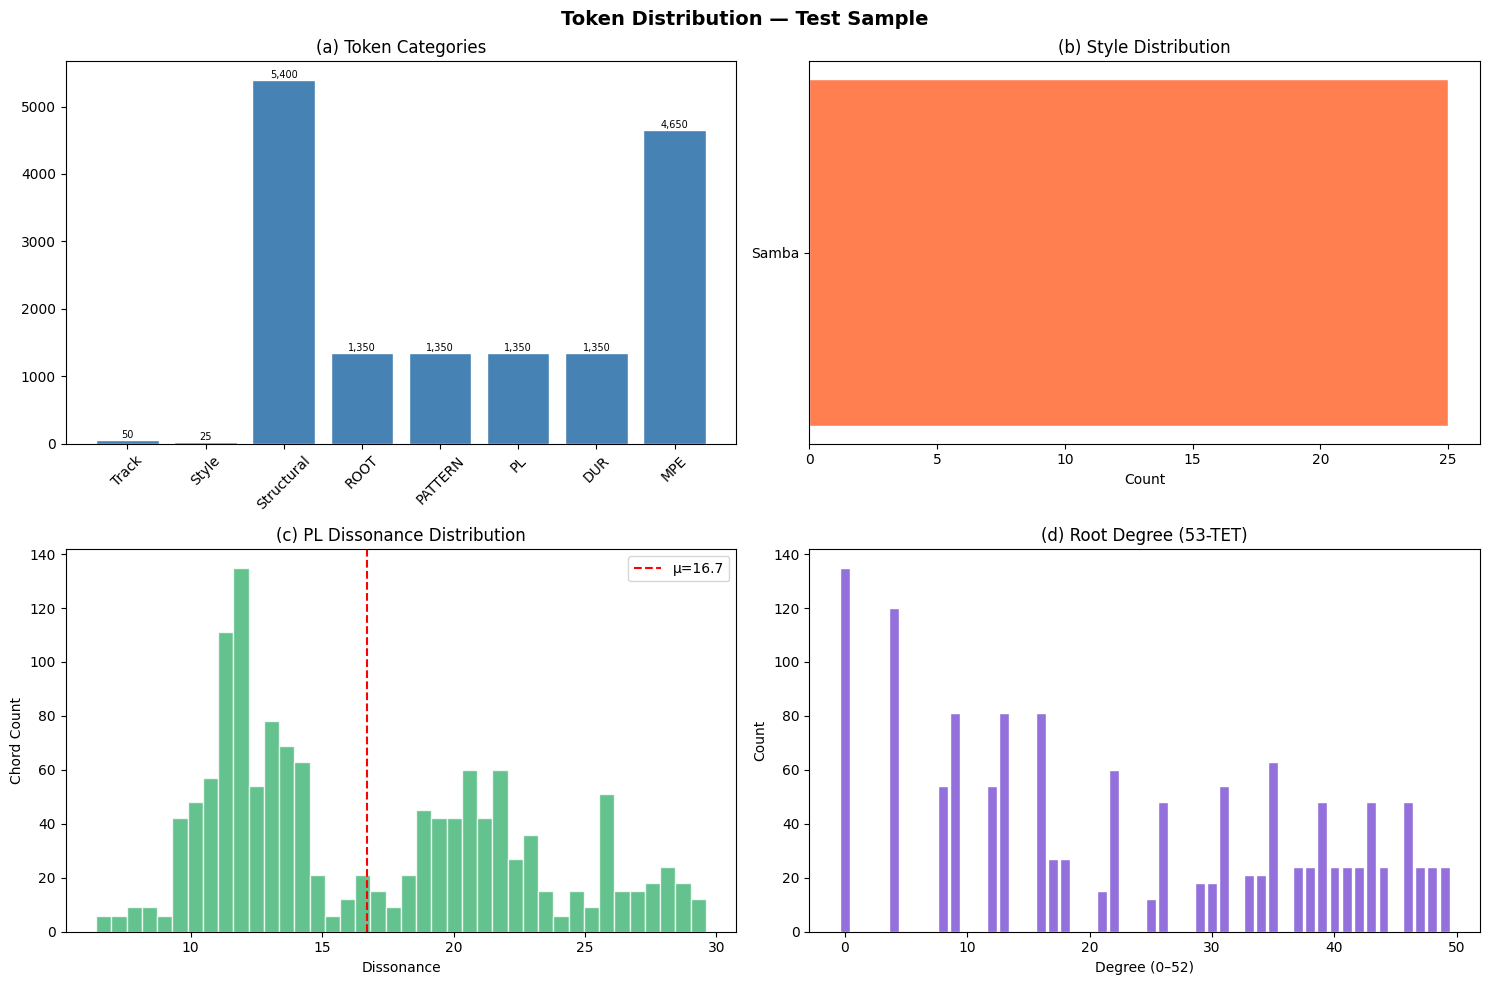

In [8]:
# ── Token Distribution Plots ─────────────────────────────────────────────
counts = stats['token_counts']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Token Distribution — Test Sample', fontsize=14, fontweight='bold')

# (a) Category totals
cats = {
    'Track':      sum(v for k, v in counts.items() if k in ('<START>', '<END>')),
    'Style':      sum(v for k, v in counts.items() if k.startswith('STYLE_')),
    'Structural': sum(v for k, v in counts.items()
                      if k.startswith('<') and k not in ('<START>', '<END>')),
    'ROOT':       sum(v for k, v in counts.items() if k.startswith('ROOT_')),
    'PATTERN':    sum(v for k, v in counts.items() if k.startswith('PATTERN_')),
    'PL':         sum(v for k, v in counts.items() if k.startswith('PL_')),
    'DUR':        sum(v for k, v in counts.items() if k.startswith('DUR_')),
    'MPE':        sum(v for k, v in counts.items() if k.startswith('MPE_')),
}
ax = axes[0, 0]
bars = ax.bar(cats.keys(), cats.values(), color='steelblue', edgecolor='white')
for b, v in zip(bars, cats.values()):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f'{v:,}',
            ha='center', va='bottom', fontsize=7)
ax.set_title('(a) Token Categories')
ax.tick_params(axis='x', rotation=45)

# (b) Style distribution
ax = axes[0, 1]
sty = {k.replace('STYLE_', ''): v for k, v in counts.items() if k.startswith('STYLE_')}
if sty:
    sorted_sty = dict(sorted(sty.items(), key=lambda x: x[1], reverse=True))
    ax.barh(list(sorted_sty.keys()), list(sorted_sty.values()), color='coral', edgecolor='white')
    ax.set_title('(b) Style Distribution')
    ax.set_xlabel('Count')

# (c) PL dissonance histogram
ax = axes[1, 0]
pl_vals = []
for k, v in counts.items():
    if k.startswith('PL_'):
        p = k.split('_')
        try:
            pl_vals.extend([float(f'{p[1]}.{p[2]}')] * v)
        except (IndexError, ValueError):
            pass
if pl_vals:
    ax.hist(pl_vals, bins=40, color='mediumseagreen', edgecolor='white', alpha=0.8)
    ax.axvline(np.mean(pl_vals), color='red', ls='--', label=f'μ={np.mean(pl_vals):.1f}')
    ax.set_title('(c) PL Dissonance Distribution')
    ax.set_xlabel('Dissonance')
    ax.set_ylabel('Chord Count')
    ax.legend()

# (d) Root degree distribution
ax = axes[1, 1]
roots = {int(k.split('_')[1]): v for k, v in counts.items() if k.startswith('ROOT_')}
if roots:
    d = sorted(roots)
    ax.bar(d, [roots[x] for x in d], color='mediumpurple', edgecolor='white', width=0.8)
    ax.set_title('(d) Root Degree (53-TET)')
    ax.set_xlabel('Degree (0–52)')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

## 7 — Cross-Pattern Analysis & Song Structure

Comparison across the 5 diatonic patterns and song chord-progression lengths.

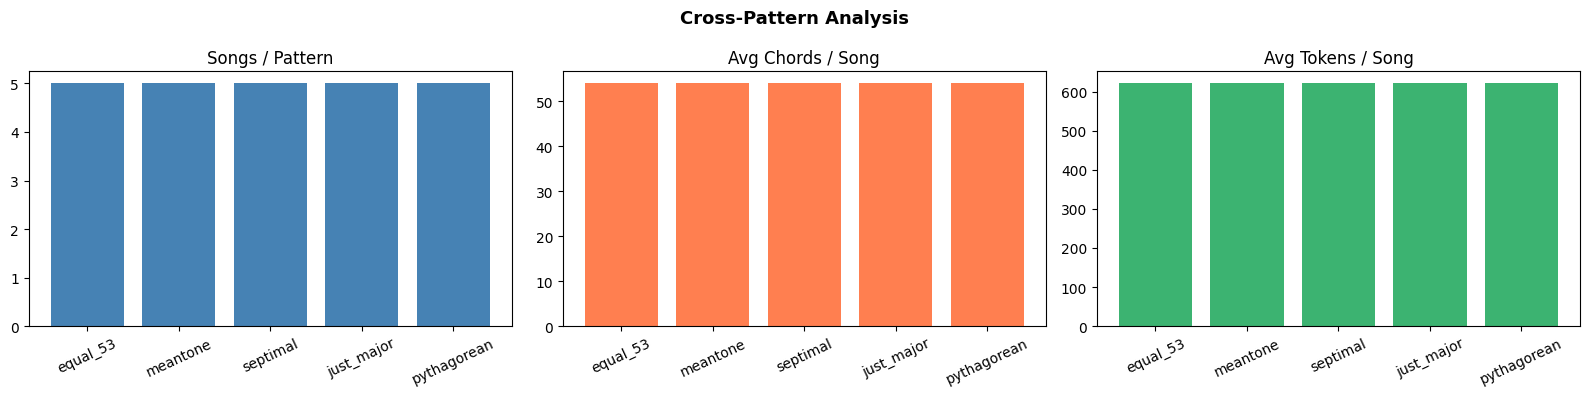

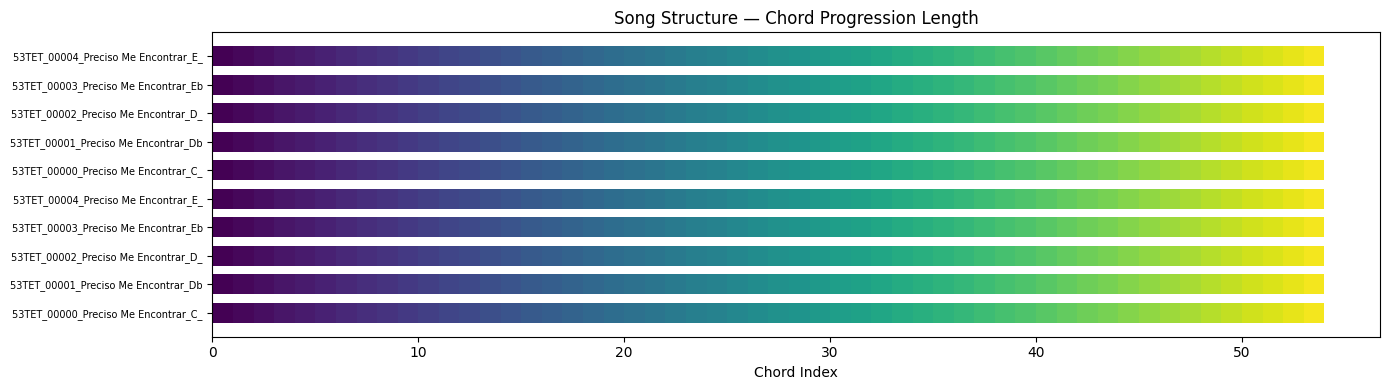


    Category   Count  Examples
────────────  ──────  ─────────────────────────────────────────────
       Track       1  <START>
       Style       1  STYLE_Samba
       Chord       2  <CHORD_END>, <CHORD_START>
        ROOT      31  ROOT_0, ROOT_12, ROOT_13, ROOT_16, ...
     PATTERN       5  PATTERN_equal_53, PATTERN_just_major, PATTERN_meantone, PATTERN_pythagorean, ...
          PL     136  PL_10_0, PL_10_1, PL_10_2, PL_10_3, ...
         DUR       3  DUR_1920, DUR_3840, DUR_960
         MPE      60  MPE_42_0, MPE_42_m1, MPE_43_0, MPE_43_m1, ...
        MIDI       2  <MIDI_END>, <MIDI_START>
       TOTAL     242


In [9]:
# ── Cross-pattern comparison ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Cross-Pattern Analysis', fontsize=13, fontweight='bold')

ps = {}
for m in stats['song_meta']:
    p = m['pattern']
    ps.setdefault(p, {'ch': 0, 'tk': 0, 'n': 0})
    ps[p]['ch'] += m['n_chords']
    ps[p]['tk'] += m['n_tokens']
    ps[p]['n']  += 1

pats   = sorted(ps.keys())
labels = [DatasetTokenizer.PATTERN_ALIASES.get(p, p) for p in pats]

axes[0].bar(labels, [ps[p]['n'] for p in pats], color='steelblue')
axes[0].set_title('Songs / Pattern')
axes[0].tick_params(axis='x', rotation=25)

axes[1].bar(labels, [ps[p]['ch'] / max(1, ps[p]['n']) for p in pats], color='coral')
axes[1].set_title('Avg Chords / Song')
axes[1].tick_params(axis='x', rotation=25)

axes[2].bar(labels, [ps[p]['tk'] / max(1, ps[p]['n']) for p in pats], color='mediumseagreen')
axes[2].set_title('Avg Tokens / Song')
axes[2].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

# ── Song structure visualization ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
n_show = min(10, len(offsets) - 1)
for i in range(n_show):
    toks = [id2tok[int(x)] for x in ids[offsets[i]:offsets[i+1]]]
    chord_pos = [j for j, t in enumerate(toks) if t == '<CHORD_START>']
    for ci, _ in enumerate(chord_pos):
        ax.barh(i, 1, left=ci, height=0.7,
                color=plt.cm.viridis(ci / max(len(chord_pos), 1)), edgecolor='none')
ax.set_yticks(range(n_show))
ax.set_yticklabels([stats['song_meta'][i]['file'][:35] for i in range(n_show)], fontsize=7)
ax.set_xlabel('Chord Index')
ax.set_title('Song Structure — Chord Progression Length')
plt.tight_layout()
plt.show()

# ── Vocabulary breakdown ─────────────────────────────────────────────────
print(f"\n{'Category':>12s}  {'Count':>6s}  Examples")
print(f"{'─'*12}  {'─'*6}  {'─'*45}")
for cat, prefix in [('Track', '<START'), ('Style', 'STYLE_'), ('Chord', '<CHORD'),
                     ('ROOT', 'ROOT_'), ('PATTERN', 'PATTERN_'), ('PL', 'PL_'),
                     ('DUR', 'DUR_'), ('MPE', 'MPE_'), ('MIDI', '<MIDI')]:
    toks = [t for t in stats['vocabulary'] if t.startswith(prefix)]
    ex = ', '.join(toks[:4]) + (', ...' if len(toks) > 4 else '')
    print(f'{cat:>12s}  {len(toks):>6d}  {ex}')
print(f"{'TOTAL':>12s}  {stats['vocab_size']:>6d}")

## 8 — Decoder & Round-Trip Verification

Parse token IDs back to structured data; verify PL dissonance round-trip.

In [10]:
def decode_song(token_ids, id2tok) -> dict:
    """Decode a song's token IDs into structured data."""
    tokens = [id2tok[int(i)] for i in token_ids]
    song = {'style': None, 'chords': []}
    i = 0
    while i < len(tokens):
        t = tokens[i]
        if t.startswith('STYLE_'):
            song['style'] = t.replace('STYLE_', '')
        elif t == '<CHORD_START>':
            chord = {'root': None, 'pattern': None, 'pl': None, 'dur': None, 'mpe': []}
            i += 1
            while i < len(tokens) and tokens[i] != '<MIDI_START>':
                tk = tokens[i]
                if tk.startswith('ROOT_'):     chord['root'] = int(tk.split('_', 1)[1])
                elif tk.startswith('PATTERN_'): chord['pattern'] = tk.split('_', 1)[1]
                elif tk.startswith('PL_'):
                    p = tk.split('_'); chord['pl'] = float(f'{p[1]}.{p[2]}')
                elif tk.startswith('DUR_'):     chord['dur'] = int(tk.split('_', 1)[1])
                i += 1
            if i < len(tokens) and tokens[i] == '<MIDI_START>':
                i += 1
                while i < len(tokens) and tokens[i] != '<MIDI_END>':
                    if tokens[i].startswith('MPE_'):
                        p = tokens[i].split('_')
                        b = 0 if p[2] == '0' else (int(p[2][1:]) if p[2][0] == 'p' else -int(p[2][1:]))
                        chord['mpe'].append((int(p[1]), b))
                    i += 1
            while i < len(tokens) and tokens[i] in ('<MIDI_END>', '<CHORD_END>'):
                i += 1
            song['chords'].append(chord)
            continue
        i += 1
    return song

# ── Decode & display first song ──────────────────────────────────────────
s0 = decode_song(ids[offsets[0]:offsets[1]], id2tok)
print(f"Style: {s0['style']}  |  Chords: {len(s0['chords'])}\n")
for c in s0['chords'][:5]:
    notes = ', '.join(f'{m}{'+' if b >= 0 else ''}{b}' for m, b in c['mpe'])
    print(f"  ROOT={c['root']:>2d}  PAT={c['pattern']:<12s}  PL={c['pl']:>5.1f}  DUR={c['dur']:>4d}  [{notes}]")

# ── PL round-trip ────────────────────────────────────────────────────────
print(f"\nPL round-trip (first 10 chords):")
ok = 0
for c in s0['chords'][:10]:
    if c['mpe']:
        recomp = generate_dissonance_token(c['mpe'])
        orig   = f"PL_{str(c['pl']).replace('.', '_')}"
        m = '✓' if recomp == orig else '✗'
        if recomp == orig: ok += 1
        print(f"  {orig:<12s} → {recomp:<12s} {m}")
print(f"\n  {ok}/{min(10, len(s0['chords']))} match — {'round-trip OK' if ok == min(10, len(s0['chords'])) else 'some mismatches'}")

Style: Samba  |  Chords: 54

  ROOT= 0  PAT=equal_53      PL= 13.9  DUR=3840  [48+0, 51-1, 55-2]
  ROOT=33  PAT=equal_53      PL= 15.2  DUR=3840  [44-2, 48+0, 53-1]
  ROOT=37  PAT=equal_53      PL= 16.6  DUR=1920  [45-3, 48+0, 51-1]
  ROOT=29  PAT=equal_53      PL= 29.6  DUR=1920  [43-2, 47-3, 50-1, 53-1]
  ROOT= 0  PAT=equal_53      PL= 13.9  DUR=1920  [48+0, 51-1, 55-2]

PL round-trip (first 10 chords):
  PL_13_9      → PL_13_9      ✓
  PL_15_2      → PL_15_2      ✓
  PL_16_6      → PL_16_6      ✓
  PL_29_6      → PL_29_6      ✓
  PL_13_9      → PL_13_9      ✓
  PL_22_8      → PL_22_8      ✓
  PL_22_7      → PL_22_7      ✓
  PL_13_9      → PL_13_9      ✓
  PL_15_2      → PL_15_2      ✓
  PL_22_7      → PL_22_7      ✓

  10/10 match — round-trip OK


## 9 — Full Dataset Tokenization

Process all ~240k MIDI files → `tokens.npy` + `offsets.npy`.

> **Runtime**: ~30–60 min. Verify test results above first.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# Full dataset tokenization — uncomment and run when ready
# ══════════════════════════════════════════════════════════════════════════

full_dir   = OUTPUT_DIR / 'full'
full_stats = tokenizer.tokenize_dataset(full_dir)

print(f"Full dataset written to {full_dir}")
print(f"  Songs:  {full_stats['total_songs']:>10,}")
print(f"  Chords: {full_stats['total_chords']:>10,}")
print(f"  Tokens: {full_stats['total_tokens']:>10,}")
print(f"  Vocab:  {full_stats['vocab_size']:>10,}")
print(f"\n  tokens.npy  → {(full_dir / 'tokens.npy').stat().st_size / 1e6:.1f} MB")
print(f"  offsets.npy → {(full_dir / 'offsets.npy').stat().st_size / 1e3:.1f} KB")

---

## Architecture Reference

### Encoded Token Stream (single song)
```
<START> STYLE_Jazz
  <CHORD_START> ROOT_0 PATTERN_pythagorean PL_18_4 DUR_960
    <MIDI_START> MPE_48_0 MPE_55_p1 MPE_60_0 MPE_64_m1 MPE_67_p2 <MIDI_END>
  <CHORD_END>
  <CHORD_START> ROOT_31 PATTERN_pythagorean PL_22_1 DUR_480
    <MIDI_START> MPE_55_p1 MPE_60_0 MPE_62_p2 MPE_67_0 <MIDI_END>
  <CHORD_END>
  ...
<END>
```

### Output Files
| File | Format | Content |
|------|--------|---------|
| `tokens.npy` | `int32` | Flat token-ID array (all songs concatenated) |
| `offsets.npy` | `int64` | `[0, len(song0), len(song0)+len(song1), ...]` |
| `vocab.json` | JSON | `{tok2id: {...}, id2tok: {...}}` |
| `stats.json` | JSON | Song/chord/token counts |

### Removed (Legacy) Tokens
| Token | Reason |
|-------|--------|
| `CH_<c>` | MPE implementation detail |
| `TIME_<t>` | Block chords are simultaneous |
| `NDUR_<d>` | All notes share `DUR_<d>` |
| `VOICING_<v>` | Encoded by MPE note list |
| Chord names | Lossy abstractions — root + MPE defines chord |